In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

!pip install catboost
from catboost import CatBoostClassifier

In [ ]:
df = pd.read_csv('heart .csv')

print(df.columns)

# 🔥 Feature Engineering
df['BP_HR_Ratio'] = df['RestingBP'] / (df['MaxHR'] + 1)
df['Chol_Age'] = df['Cholesterol'] * df['Age']

# Convert 'ExerciseAngina' to numerical (0 or 1) before using it in calculations
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0}).astype(int)
df['Stress_Index'] = df['Oldpeak'] * df['ExerciseAngina']

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# ✅ FIXED TARGET COLUMN
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [ ]:
# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Only for Logistic + SVM
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=3000) # Increased max_iter

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)

# XGBoost
xgb_model = XGBClassifier( eval_metric='logloss',scale_pos_weight=1.2,random_state=42)

# LightGBM
lgb_model = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# CatBoost
cat_model = CatBoostClassifier(iterations=500, learning_rate=0.05, verbose=0)

# Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)

In [ ]:
models = [
    (log_model, "Logistic Regression"),
    (rf_model, "Random Forest"),
    (xgb_model, "XGBoost"),
    (lgb_model, "LightGBM"),
    (cat_model, "CatBoost"),
    (nn_model, "Neural Network")
]

for model, name in models:
    model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 845
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [ ]:
print("---- MODEL ACCURACY ----")

for model, name in models:
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(name, ":", acc)

---- MODEL ACCURACY ----
Logistic Regression : 0.8858695652173914
Random Forest : 0.8913043478260869
XGBoost : 0.8586956521739131
LightGBM : 0.8586956521739131
CatBoost : 0.8858695652173914
Neural Network : 0.5489130434782609


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(rf_model, rf_param, cv=3, n_iter=20, random_state=42)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("🔥 Tuned Random Forest Accuracy:", rf_acc)

🔥 Tuned Random Forest Accuracy: 0.8913043478260869


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [700, 900, 1200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.02],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 0.05],
    'reg_lambda': [1, 2, 5],
    'min_child_weight': [1, 3]
}

search = RandomizedSearchCV(xgb_model, param_dist, cv=3, n_iter=40,random_state=42)
search.fit(X_train, y_train)

best_model = search.best_estimator_

pred = best_model.predict(X_test)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, pred))

Tuned XGBoost Accuracy: 0.8858695652173914


In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_model),
        ('lr', log_model),
        ('rf', rf_best)
    ],
    voting='soft',
    weights=[5,2, 1, ]   # 🔥 Give importance to XGBoost, added weight for Logistic Regression and Random Forest
)
ensemble.fit(X_train, y_train)

pred = ensemble.predict(X_test)
print("Voting Classifier Accuracy:", accuracy_score(y_test, pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting Classifier Accuracy: 0.8967391304347826


In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_model),

        ('rf', rf_best)
    ],
    voting='soft',
    weights=[6, 1, ]   # 🔥 Give importance to XGBoost, added weight for Logistic Regression and Random Forest
)
ensemble.fit(X_train, y_train)

pred = ensemble.predict(X_test)
print("Voting Classifier Accuracy:", accuracy_score(y_test, pred))

Voting Classifier Accuracy: 0.8858695652173914


In [ ]:
# Ensemble 1 (3 Models)
ensemble_3 = VotingClassifier(
    estimators=[
        ('xgb', best_model),
        ('lr', log_model),
        ('rf', rf_best)
    ],
    voting='soft',
    weights=[5,2,1]
)

ensemble_3.fit(X_train, y_train)
pred3 = ensemble_3.predict(X_test)
print("Ensemble (3 Models) Accuracy:", accuracy_score(y_test, pred3))


# Ensemble 2 (2 Models)
ensemble_2 = VotingClassifier(
    estimators=[
        ('xgb', best_model),
        ('rf', rf_best)
    ],
    voting='soft',
    weights=[6,1]
)

ensemble_2.fit(X_train, y_train)
pred2 = ensemble_2.predict(X_test)
print("Ensemble (2 Models) Accuracy:", accuracy_score(y_test, pred2))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble (3 Models) Accuracy: 0.8967391304347826
Ensemble (2 Models) Accuracy: 0.8858695652173914


In [ ]:
final_model = ensemble_3

In [ ]:
pred = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, pred))

Final Accuracy: 0.8967391304347826


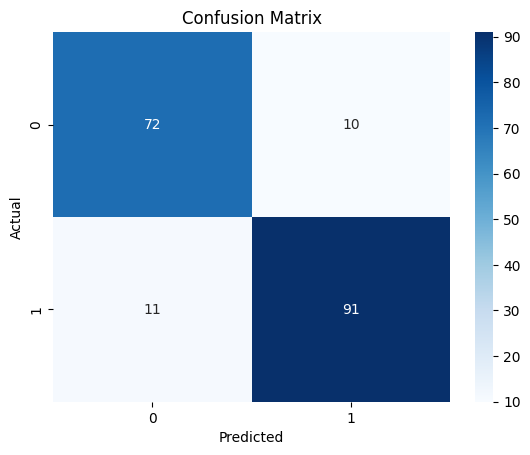

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import smtplib
from email.mime.text import MIMEText

def send_email(name, age, risk_percent, status, reasons, suggestions, confidence, severity, time_now):

    sender = "sanjaygandhi959@gmail.com"
    receiver = ["sanjaydu333@gmail.com", "praneshselvam1@gmail.com"]
    password = "kyxuenmmaurmumbk"

    subject = "Heart Disease Prediction Alert"

    # Convert list → bullet format
    reasons_text = "\n".join(["• " + r for r in reasons])
    suggestions_text = "\n".join(["• " + s for s in suggestions])

    body = f"""
Heart Disease Prediction Report

Patient Name: {name}
Age: {age}

Risk Score: {risk_percent}%
Confidence: {confidence}%
Status: {status}
Severity: {severity}
Generated At: {time_now}

Reasons:
{reasons_text}

Suggestions:
{suggestions_text}

-- AI Health Monitoring System
"""

    msg = MIMEText(body)
    msg['Subject'] = subject
    msg['From'] = sender
    msg['To'] = ", ".join(receiver)

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender, password)
        server.sendmail(sender, receiver, msg.as_string())
        server.quit()
        print("✅ Email sent successfully!")

    except Exception as e:
        print("❌ Error:", e)

In [ ]:
new_patient = pd.DataFrame([{
    "Name": "P.Narayana",

    "Age": 45,
    "Sex": 1,
    "ChestPainType": 1,
    "RestingBP": 120,       # Normal
    "Cholesterol": 320,     # 🔴 High (ONLY RISK)
    "FastingBS": 0,
    "RestingECG": 0,
    "MaxHR": 150,           # Normal
    "ExerciseAngina": 0,
    "Oldpeak": 0.5,
    "ST_Slope": 1
}])



In [ ]:
# ================= EXTRACT PATIENT INFO =================
patient_name = new_patient.iloc[0]['Name']
patient_age = new_patient.iloc[0]['Age']

# ================= PREPROCESSING NEW PATIENT DATA =================

new_patient_processed = new_patient.drop('Name', axis=1).copy()


# Extract relevant features from new_patient for `get_dummies`
patient_features = new_patient.drop(columns=['Name'])

# Perform one-hot encoding on the new patient data
# It's crucial to align these columns with the ones X_train was trained on.
# We will create a dummy DataFrame that contains all possible dummy columns from the original training set
# and then merge the new patient data into it.

# Get the columns from the original X before scaling
original_X_columns = X.columns

# Apply get_dummies to the new patient features
patient_features_encoded = pd.get_dummies(patient_features, drop_first=True)

# Reindex the encoded new patient features to match the columns of the original X (before scaling)
# Fill missing columns (if any, for categories not present in new_patient) with 0
model_input_aligned = patient_features_encoded.reindex(columns=original_X_columns, fill_value=0)

# 🔥 The ensemble models were trained on unscaled data, so use model_input_aligned directly.
# If individual models within the ensemble required scaling, they would need to be handled separately.
model_input = model_input_aligned


# ================= STEP 1: PREDICTION =================
prob = ensemble.predict_proba(model_input)[0][1]
risk_percent = round(prob * 100, 2)

confidence = max(prob, 1 - prob) * 100

# ================= STEP 2: STATUS =================
if risk_percent >= 70:
    status = "🔴 HIGH RISK"
elif risk_percent >= 40:
    status = "🟡 MODERATE RISK"
else:
    status = "🟢 LOW RISK"

# This is a separate block for severity, not nested under the 'else' above
if risk_percent >= 80:
    severity = "CRITICAL"
elif risk_percent >= 60:
    severity = "HIGH"
elif risk_percent >= 40:
    severity = "MODERATE"
else:
    severity = "LOW"

# ================= STEP 3: REASONS =================
# Initialize reasons as an empty list to avoid NameError if 'reasons' is not defined before this line.

# STEP 3: REASONS (FOR ANY RISK LEVEL)
reasons = []

if new_patient["RestingBP"][0] > 140:
    reasons.append("High Blood Pressure")

if new_patient["Cholesterol"][0] > 250:
    reasons.append("High Cholesterol")

# Accessing using the original new_patient df, as these are the raw values
if new_patient["ExerciseAngina"][0] == 1:
    reasons.append("Exercise-induced chest pain")

if new_patient["Oldpeak"][0] > 2:
    reasons.append("Abnormal ECG depression")

if new_patient["MaxHR"][0] < 120:
    reasons.append("Low heart rate response")

# Limit top 3
reasons = reasons[:3]



# ================= STEP 4: SUGGESTIONS =================
suggestions = []

for r in reasons:
    if r == "High Blood Pressure":
        suggestions.append("Control BP with low-salt diet")

    elif r == "High Cholesterol":
        suggestions.append("Adopt a low-fat, heart-healthy diet")

    elif r == "Exercise-induced chest pain":
        suggestions.append("Avoid heavy physical exertion")

    elif r == "Abnormal ECG depression":
        suggestions.append("Consult cardiologist for ECG evaluation")

    elif r == "Low heart rate response":
        suggestions.append("Monitor heart rate and avoid stress")

# ================= REMOVE DUPLICATES (IMPORTANT) =================
reasons = list(dict.fromkeys(reasons))
suggestions = list(dict.fromkeys(suggestions))



 #Date and  Time
from datetime import datetime
time_now = datetime.now().strftime("%d %b %Y, %I:%M %p")

# ================= STEP 5: OUTPUT =================
# ================= STEP 5: FINAL OUTPUT =================

from datetime import datetime

# 🔥 Time
time_now = datetime.now().strftime("%d-%m-%Y %H:%M")

print("\n===== SMART HEALTH REPORT =====")
print(f"Patient: {patient_name}")
print(f"Age: {patient_age}")

print(f"\nRisk Score: {risk_percent}%")
print(f"Confidence: {confidence}%")     # 🔥 Added
print(f"Status: {status}")
print(f"Severity: {severity}")          # 🔥 Added
print(f"Generated At: {time_now}")      # 🔥 Added

# 🔍 Reasons
print("\n🔍 Reasons:")
if reasons:
    for r in reasons:
        print("-", r)
else:
    print("- No major risk factors detected")

# 💡 Suggestions:")
if suggestions:
    for s in suggestions:
        print("-", s)
else:
    print("- Maintain healthy lifestyle")

print("\n=================================")


# ================= SEND EMAIL =================
send_email(
    patient_name,
    patient_age,
    risk_percent,
    status,
    reasons,
    suggestions,
    confidence,
    severity,
    time_now
)


===== SMART HEALTH REPORT =====
Patient: P.Narayana
Age: 45

Risk Score: 52.61%
Confidence: 52.610089606643726%
Status: 🟡 MODERATE RISK
Severity: MODERATE
Generated At: 28-04-2026 05:54

🔍 Reasons:
- High Cholesterol
- Adopt a low-fat, heart-healthy diet

✅ Email sent successfully!
